# 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

Install Dependencies

In [19]:
!pip install nltk wordcloud contractions
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Load the dataset

In [20]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/AI & Machine Learning/Assessment/5. Movie Review Dataset/train_movie_review.csv')
val_df = pd.read_csv('/content/drive/MyDrive/AI & Machine Learning/Assessment/5. Movie Review Dataset/val_movie_review.csv')
test_df = pd.read_csv('/content/drive/MyDrive/AI & Machine Learning/Assessment/5. Movie Review Dataset/test_movie_review.csv')

Check shapes and columns

In [21]:
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("\nColumn names:", train_df.columns.tolist())

Train shape: (35000, 3)
Val shape: (5000, 3)
Test shape: (10000, 3)

Column names: ['Unnamed: 0', 'review', 'sentiment']


Class distribution

In [22]:
print("Class distribution (train):")
print(train_df['sentiment'].value_counts())

print("\nClass distribution (val):")
print(val_df['sentiment'].value_counts())

print("\nClass distribution (test):")
print(test_df['sentiment'].value_counts())

Class distribution (train):
sentiment
0    17584
1    17416
Name: count, dtype: int64

Class distribution (val):
sentiment
1    2545
0    2455
Name: count, dtype: int64

Class distribution (test):
sentiment
1    5039
0    4961
Name: count, dtype: int64


Preview the data

In [23]:
display(train_df.head())

,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


Drop the unnecessary column and reset the dataframes

In [24]:
# Drop the unnamed index column
train_df = train_df.drop(columns=['Unnamed: 0'])
val_df   = val_df.drop(columns=['Unnamed: 0'])
test_df  = test_df.drop(columns=['Unnamed: 0'])

# Confirm
display(train_df.head())

,review,sentiment
0,"Having avoided seeing the movie in the cinema,...",0
1,With this movie I was really hoping that the i...,0
2,Raymond Burr stars as an attorney caught up in...,0
3,A lot people get hung up on this films tag as ...,1
4,I was a fan of Buffy and hoped it would come t...,0


Text cleaning

In [25]:
import re
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                           # lowercase
    text = re.sub(r'<br\s*/?>', ' ', text)        # remove <br> tags first
    text = contractions.fix(text)                 # don't → do not
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = re.sub(r'@\w+', '', text)              # remove mentions
    text = re.sub(r'#\w+', '', text)              # remove hashtags
    text = re.sub(r'\d+', '', text)               # remove numbers
    text = re.sub(r'[^a-z\s]', '', text)          # remove special characters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

train_df['cleaned'] = train_df['review'].apply(clean_text)
val_df['cleaned']   = val_df['review'].apply(clean_text)
test_df['cleaned']  = test_df['review'].apply(clean_text)

print("Cleaning done!")
print(f"Train: {len(train_df)} rows")

Cleaning done!
Train: 35000 rows


Verify cleaning worked

In [26]:
for i in range(3):
    print(f"--- Example {i+1} ---")
    print(f"ORIGINAL: {train_df['review'].iloc[i][:200]}")
    print(f"CLEANED:  {train_df['cleaned'].iloc[i][:200]}")
    print()

--- Example 1 ---
ORIGINAL: Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -
CLEANED:  avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race al

--- Example 2 ---
ORIGINAL: With this movie I was really hoping that the idea was to make up for the hashed together ineptitude of the first AVP, and yet to my horror: Requiem is far worse than I could have imagined.<br /><br />
CLEANED:  movie really hoping idea make hashed together ineptitude first avp yet horror requiem far worse could imagined hope opening moment film inside predator ship almost breathed sigh relief finally saw pre

--- Example 3 ---
ORIGINAL: Raymond Burr stars as an attorney caught up in the murder of his best friend (Dick Foran) 

Word cloud

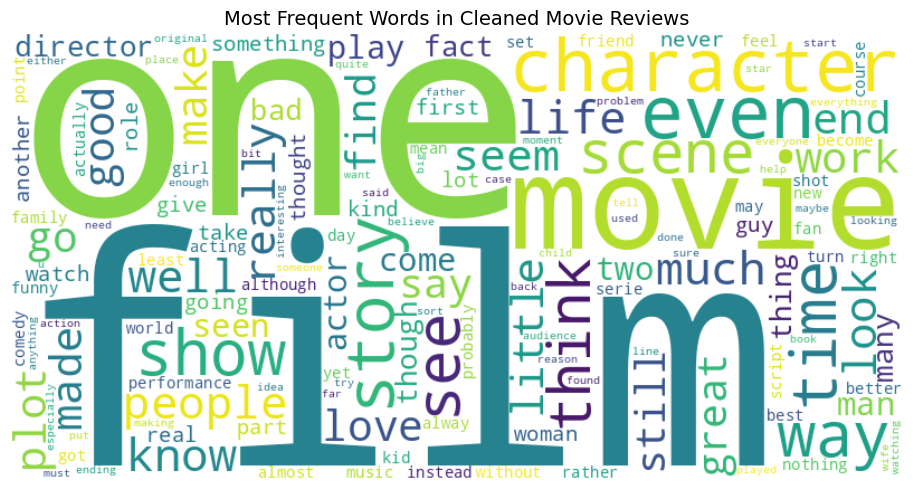

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = ' '.join(train_df['cleaned'])

wc = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Cleaned Movie Reviews', fontsize=14)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

Top 20 most frequent words bar chart

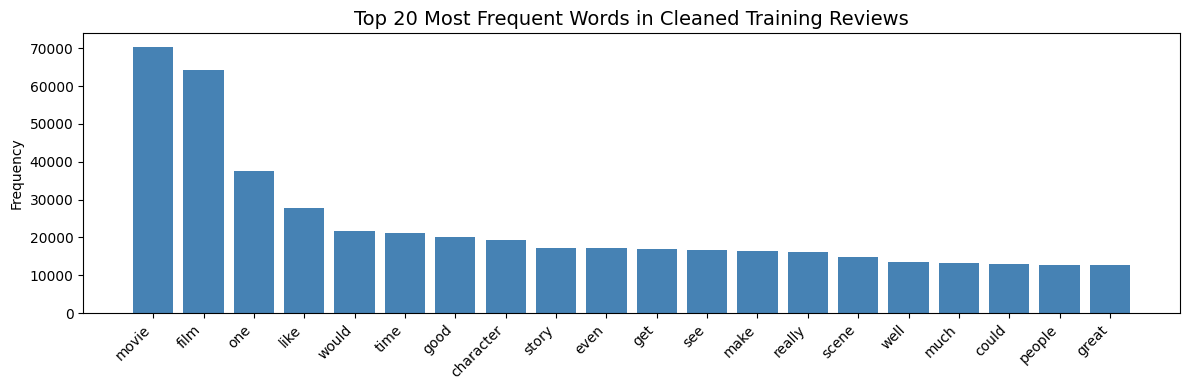

In [38]:
from collections import Counter

word_freq = Counter(' '.join(train_df['cleaned']).split())
top20 = word_freq.most_common(20)
words, counts = zip(*top20)

plt.figure(figsize=(12, 4))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words in Cleaned Training Reviews', fontsize=14)
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('top20_words.png', dpi=150)
plt.show()

Tokenization

In [39]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned'])  # fit on training data only

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

print(f"Vocabulary size: {vocab_size}")
print(f"Sample word indices:")
print(dict(list(word_index.items())[:10]))

Vocabulary size: 122062
Sample word indices:
{'<OOV>': 1, 'movie': 2, 'film': 3, 'one': 4, 'like': 5, 'would': 6, 'time': 7, 'good': 8, 'character': 9, 'story': 10}


Convert to sequences

In [40]:
X_train_seq = tokenizer.texts_to_sequences(train_df['cleaned'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['cleaned'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['cleaned'])

print(f"Sample sequence (first review):")
print(X_train_seq[0][:20], "...")

Sample sequence (first review):
[3871, 202, 2, 313, 2440, 162, 212, 15737, 33, 382, 18, 481, 167, 12, 13413, 28446, 8952, 1758, 1758, 20269] ...


Calculate percentile-based padding length

Average sequence length:        116
Median sequence length:         87
90th percentile length:         229
95th percentile length:         301
99th percentile length:         454
Max sequence length:            1416


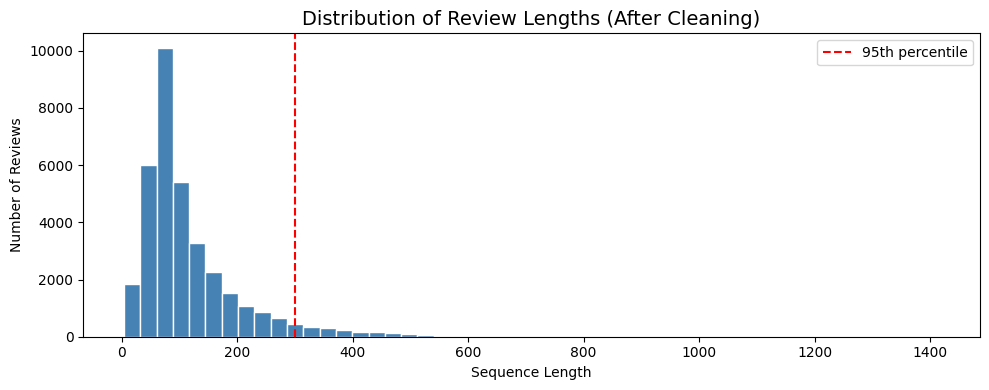

In [41]:
import numpy as np

lengths = [len(seq) for seq in X_train_seq]

print(f"Average sequence length:        {int(np.mean(lengths))}")
print(f"Median sequence length:         {int(np.median(lengths))}")
print(f"90th percentile length:         {int(np.percentile(lengths, 90))}")
print(f"95th percentile length:         {int(np.percentile(lengths, 95))}")
print(f"99th percentile length:         {int(np.percentile(lengths, 99))}")
print(f"Max sequence length:            {int(np.max(lengths))}")

# Visualise the distribution
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(int(np.percentile(lengths, 95)), color='red', linestyle='--', label='95th percentile')
plt.title('Distribution of Review Lengths (After Cleaning)', fontsize=14)
plt.xlabel('Sequence Length')
plt.ylabel('Number of Reviews')
plt.legend()
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150)
plt.show()

Apply padding

In [42]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 301  # 95th percentile

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print("Padded shapes:")
print(f"X_train: {X_train_pad.shape}")
print(f"X_val:   {X_val_pad.shape}")
print(f"X_test:  {X_test_pad.shape}")

Padded shapes:
X_train: (35000, 301)
X_val:   (5000, 301)
X_test:  (10000, 301)


# Task 4.5.2 — Model Building

Model 1: Simple RNN

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

vocab_size    = 122062
embedding_dim = 64

model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model1.build(input_shape=(None, max_len))

model1.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 301, 64)        │     7,811,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,820,289 (29.83 MB)

 Trainable params: 7,820,289 (29.83 MB)

 Non-trainable params: 0 (0.00 B)

Model 2: LSTM

In [44]:
from tensorflow.keras.layers import LSTM

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model2.build(input_shape=(None, max_len))

model2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 301, 64)        │     7,811,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,845,057 (29.93 MB)

 Trainable params: 7,845,057 (29.93 MB)

 Non-trainable params: 0 (0.00 B)

Model 3: LSTM with GloVe embeddings

In [45]:
!pip install gensim --quiet

import gensim.downloader as api

print("Downloading GloVe embeddings... this may take a few minutes.")
embedding_model_w2v = api.load('glove-wiki-gigaword-300')
print("Download complete!")

Download complete!


Build the embedding matrix and Model 3

In [47]:
embedding_dim_w2v = 300

embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))
found = 0

for word, i in word_index.items():
    if word in embedding_model_w2v:
        embedding_matrix[i] = embedding_model_w2v[word]
        found += 1

print(f"Words found in GloVe:     {found}")
print(f"Words not found in GloVe: {vocab_size - found}")
print(f"Coverage:                 {found/vocab_size*100:.1f}%")

model3 = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim_w2v,
              weights=[embedding_matrix],
              trainable=True),       # ← changed to True
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model3.build(input_shape=(None, max_len))

model3.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model3.summary()

Words found in GloVe:     59654
Words not found in GloVe: 62408
Coverage:                 48.9%


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 301, 300)       │    36,618,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,712,105 (140.05 MB)

 Trainable params: 36,712,105 (140.05 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4.5.3 — Training

Train Model 1

In [48]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 1 - Simple RNN...")
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

Training Model 1 - Simple RNN...
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 100s 172ms/step - accuracy: 0.5016 - loss: 0.6944 - val_accuracy: 0.5010 - val_loss: 0.6929
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 144s 176ms/step - accuracy: 0.5311 - loss: 0.6833 - val_accuracy: 0.5100 - val_loss: 0.6937
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 140s 172ms/step - accuracy: 0.5348 - loss: 0.6758 - val_accuracy: 0.4928 - val_loss: 0.6939
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 140s 169ms/step - accuracy: 0.5392 - loss: 0.6654 - val_accuracy: 0.4952 - val_loss: 0.6956


Train Model 2: LSTM

In [49]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 2 - LSTM...")
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

Training Model 2 - LSTM...
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 168s 302ms/step - accuracy: 0.5040 - loss: 0.6933 - val_accuracy: 0.4960 - val_loss: 0.6931
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 200s 299ms/step - accuracy: 0.5118 - loss: 0.6924 - val_accuracy: 0.4960 - val_loss: 0.6930
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 206s 307ms/step - accuracy: 0.5205 - loss: 0.6849 - val_accuracy: 0.4982 - val_loss: 0.7016
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 161s 294ms/step - accuracy: 0.5274 - loss: 0.6685 - val_accuracy: 0.4992 - val_loss: 0.7040
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 202s 294ms/step - accuracy: 0.5328 - loss: 0.6595 - val_accuracy: 0.4924 - val_loss: 0.7406


Train Model 3 (LSTM + GloVe)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 3 - LSTM with GloVe embeddings...")
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

Cell 22 — Plot training curves for all three models

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train loss', marker='o')
    ax1.plot(history.history['val_loss'], label='Val loss', marker='o')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train accuracy', marker='o')
    ax2.plot(history.history['val_accuracy'], label='Val accuracy', marker='o')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()

plot_history(history1, 'Model 1 Simple RNN')
plot_history(history2, 'Model 2 LSTM')
plot_history(history3, 'Model 3 LSTM GloVe')

Cell 23 — Evaluate all three models on the test set

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, name):
    y_pred_prob = model.predict(X_test_pad)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    print(f'\n{"="*50}')
    print(f'{name}')
    print(f'{"="*50}')
    print(f'Test Accuracy: {acc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ", "_")}_cm.png', dpi=150)
    plt.show()

    return acc

acc1 = evaluate_model(model1, 'Model 1 Simple RNN')
acc2 = evaluate_model(model2, 'Model 2 LSTM')
acc3 = evaluate_model(model3, 'Model 3 LSTM GloVe')

Cell 24 — Model comparison bar chart

In [ ]:
models = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + GloVe']
accuracies = [0.5002, 0.8714, 0.5706]
colors = ['#d9534f', '#5cb85c', '#f0ad4e']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.ylim(0, 1.0)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random baseline')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontsize=12, fontweight='bold')
plt.title('Test Accuracy Comparison — All Three Models', fontsize=14)
plt.ylabel('Test Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

Cell 25 — Error analysis on Model 2 (our best model)

In [ ]:
import numpy as np

y_pred_prob2 = model2.predict(X_test_pad)
y_pred2 = (y_pred_prob2 > 0.5).astype(int).flatten()

# Find misclassified indices
errors = np.where(y_pred2 != y_test)[0]
print(f"Total misclassified by Model 2: {len(errors)} out of {len(y_test)}")
print(f"Error rate: {len(errors)/len(y_test)*100:.2f}%\n")

# Display 5 misclassified examples
for i in errors[:5]:
    true_label = "Positive" if y_test[i] == 1 else "Negative"
    pred_label = "Positive" if y_pred2[i] == 1 else "Negative"
    confidence = float(y_pred_prob2[i][0])
    if y_pred2[i] == 0:
        confidence = 1 - confidence
    print(f"--- Example {i} ---")
    print(f"Original review: {test_df['review'].iloc[i][:300]}")
    print(f"Cleaned review:  {test_df['cleaned'].iloc[i][:200]}")
    print(f"True label:      {true_label}")
    print(f"Predicted:       {pred_label}")
    print(f"Confidence:      {confidence:.2%}")
    print()

Cell 26 — Final comparison summary table

In [ ]:
results = {
    'Model': ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Test Accuracy': ['50.02%', '87.14%', '57.06%'],
    'Precision (avg)': ['0.52', '0.87', '0.70'],
    'Recall (avg)': ['0.50', '0.87', '0.57'],
    'F1-Score (avg)': ['0.37', '0.87', '0.49'],
    'Epochs Run': [5, 8, 7]
}

results_df = pd.DataFrame(results)
display(results_df)

Cell 27 — Install Gradio

In [ ]:
!pip install gradio --quiet
print("Gradio installed!")

Cell 28 — Save the tokenizer and check model is ready

In [ ]:
import pickle

# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved!")
print(f"Model 2 ready: {model2.built}")
print(f"Max length: {max_len}")
print(f"Vocab size: {vocab_size}")

Cell 29 — Build and launch the Gradio GUI

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(review):
    # Clean the input
    cleaned = clean_text(review)

    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # Predict
    prob = float(model2.predict(padded, verbose=0)[0][0])

    if prob > 0.5:
        label = "Positive 😊"
        confidence = prob
    else:
        label = "Negative 😞"
        confidence = 1 - prob

    return {
        "Sentiment": label,
        "Confidence": f"{confidence:.2%}",
        "Positive probability": f"{prob:.2%}",
        "Negative probability": f"{1-prob:.2%}"
    }

# Build the interface
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter a movie review here...",
        label="Movie Review"
    ),
    outputs=gr.JSON(label="Prediction Results"),
    title="🎬 Movie Review Sentiment Analyser",
    description="Enter any movie review and the LSTM model will predict whether it is positive or negative.",
    examples=[
        ["This movie was absolutely fantastic! The acting was superb and the story kept me engaged throughout."],
        ["What a waste of time. Terrible acting, boring plot and I almost fell asleep halfway through."],
        ["It was okay, nothing special but not terrible either. Some good moments but mostly forgettable."]
    ]
)

demo.launch(share=True, debug=False)